<a href="https://colab.research.google.com/github/Mayo-27-git/Major-Project/blob/main/PIX2PIX_%5B250%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_dir = 'content/drive/MyDrive/FINAL PROJECT'
image_dir = os.path.join(data_dir, 'REAL IMAGES')
mask_dir = os.path.join(data_dir, 'NVIDIA MASKS')
output_dir = os.path.join(data_dir, 'masked_images')

In [ ]:


output_dir = '/content/drive/MyDrive/FINAL PROJECT/masked_images'

print("Masked images are stored in:", output_dir)


Masked images are stored in: /content/drive/MyDrive/FINAL PROJECT/masked_images


In [ ]:

os.makedirs(output_dir, exist_ok=True)

In [ ]:

image_dir = "/content/drive/MyDrive/FINAL PROJECT/REAL IMAGES"
mask_dir = "/content/drive/MyDrive/FINAL PROJECT/NVIDIA MASKS"

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))
print(len(image_files))
print(len(mask_files))

3000
3000


In [ ]:

assert len(image_files) == len(mask_files), "Mismatch in number of images and masks."

In [ ]:
for img_name, mask_name in zip(image_files, mask_files):

    img = cv2.imread(os.path.join(image_dir, img_name))
    mask = cv2.imread(os.path.join(mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)


    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
    mask = mask / 255
    mask = np.expand_dims(mask, axis=-1)
    masked_img = img * (1 - mask)
    cv2.imwrite(os.path.join(output_dir, img_name), masked_img)

print("✅ Masks applied successfully! Masked images are saved in 'masked_images' folder.")

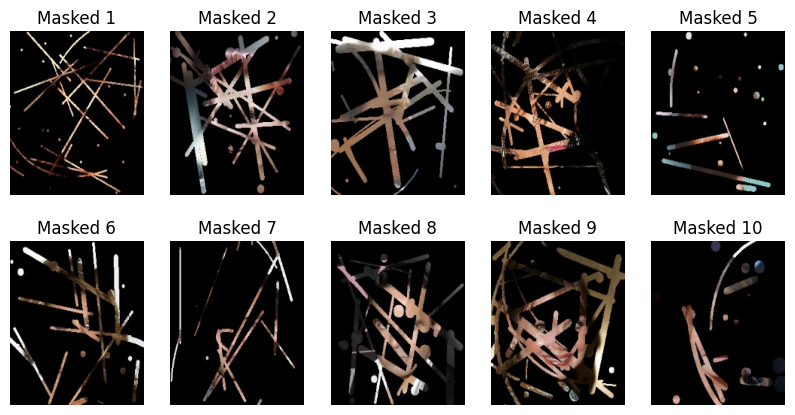

In [ ]:

masked_files = sorted(os.listdir(output_dir))
plt.figure(figsize=(10, 5))
for i, masked_img_name in enumerate(masked_files[:10]):
    img = cv2.imread(os.path.join(output_dir, masked_img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Masked {i+1}")
plt.show()


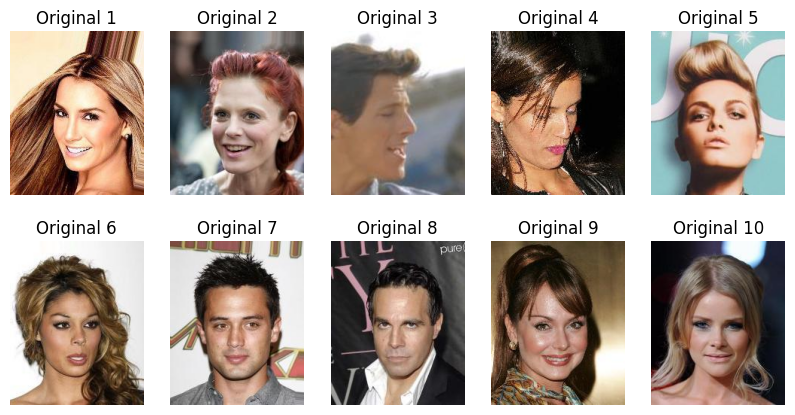

In [ ]:

plt.figure(figsize=(10, 5))
for i, original_img_name in enumerate(image_files[:10]):
    img = cv2.imread(os.path.join(image_dir, original_img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Original {i+1}")
plt.show()


In [ ]:
!pip install torch torchvision matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

class Pix2PixDataset(Dataset):
    def __init__(self, masked_files, original_files, masked_dir, original_dir, transform=None):
        self.masked_files = masked_files
        self.original_files = original_files
        self.masked_dir = masked_dir
        self.original_dir = original_dir
        self.transform = transform

    def __len__(self):
        return len(self.masked_files)

    def __getitem__(self, idx):
        masked_path = os.path.join(self.masked_dir, self.masked_files[idx])
        original_path = os.path.join(self.original_dir, self.original_files[idx])


        masked_img = cv2.imread(masked_path)
        original_img = cv2.imread(original_path)


        masked_img = cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)


        if self.transform:
            masked_img = self.transform(masked_img)
            original_img = self.transform(original_img)

        return masked_img, original_img


transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


masked_dir = "/content/drive/MyDrive/FINAL PROJECT/masked_images"
original_dir = "/content/drive/MyDrive/FINAL PROJECT/REAL IMAGES"

all_masked_files = sorted(os.listdir(masked_dir))
all_original_files = sorted(os.listdir(original_dir))


assert len(all_masked_files) == len(all_original_files), "Mismatch in masked and original images count!"


train_masked, test_masked, train_original, test_original = train_test_split(
    all_masked_files, all_original_files, test_size=0.1, random_state=42
)

train_dataset = Pix2PixDataset(train_masked, train_original, masked_dir, original_dir, transform)
test_dataset = Pix2PixDataset(test_masked, test_original, masked_dir, original_dir, transform)


train_loader = DataLoader(train_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)  # Don't shuffle test data

print(f"Total images: {len(all_masked_files)}")
print(f"Training set: {len(train_dataset)} images")
print(f"Testing set: {len(test_dataset)} images")


Total images: 3000
Training set: 2700 images
Testing set: 300 images


In [ ]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        def down_block(in_channels, out_channels, normalize=True):
            layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.LeakyReLU(0.2))
            return nn.Sequential(*layers)

        def up_block(in_channels, out_channels, dropout=False):
            layers = [nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
                      nn.BatchNorm2d(out_channels),
                      nn.ReLU()]
            if dropout:
                layers.append(nn.Dropout(0.5))
            return nn.Sequential(*layers)

        self.encoder = nn.ModuleList([
            down_block(3, 64, normalize=False),
            down_block(64, 128),
            down_block(128, 256),
            down_block(256, 512),
            down_block(512, 512),
            down_block(512, 512),
            down_block(512, 512),
            down_block(512, 512, normalize=False)
        ])

        self.decoder = nn.ModuleList([
            up_block(512, 512, dropout=True),
            up_block(1024, 512, dropout=True),
            up_block(1024, 512, dropout=True),
            up_block(1024, 512),
            up_block(1024, 256),
            up_block(512, 128),
            up_block(256, 64)
        ])

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        skips = []
        for layer in self.encoder:
            x = layer(x)
            skips.append(x)

        skips = skips[:-1][::-1]  # Reverse for skip connections

        for i, layer in enumerate(self.decoder):
            x = layer(x)
            x = torch.cat([x, skips[i]], 1)

        return self.final(x)


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        def block(in_channels, out_channels, normalize=True):
            layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.LeakyReLU(0.2))
            return nn.Sequential(*layers)

        self.model = nn.Sequential(
            block(6, 64, normalize=False),  # Input: masked image + generated image
            block(64, 128),
            block(128, 256),
            block(256, 512),
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


Epoch [1/250]  D Loss: 0.5622  G Loss: 29.4925  L1 Loss: 28.8196  GAN Loss: 0.6729
Epoch [2/250]  D Loss: 0.5174  G Loss: 23.9081  L1 Loss: 23.2214  GAN Loss: 0.6868
Epoch [3/250]  D Loss: 0.5034  G Loss: 22.3043  L1 Loss: 21.6112  GAN Loss: 0.6930
Epoch [4/250]  D Loss: 0.5178  G Loss: 21.0954  L1 Loss: 20.4064  GAN Loss: 0.6889
Epoch [5/250]  D Loss: 0.5033  G Loss: 20.3198  L1 Loss: 19.6267  GAN Loss: 0.6931
Epoch [6/250]  D Loss: 0.5420  G Loss: 19.5634  L1 Loss: 18.8976  GAN Loss: 0.6658
Epoch [7/250]  D Loss: 0.5138  G Loss: 18.9463  L1 Loss: 18.2613  GAN Loss: 0.6851
Epoch [8/250]  D Loss: 0.5167  G Loss: 18.4411  L1 Loss: 17.7636  GAN Loss: 0.6775
Epoch [9/250]  D Loss: 0.5032  G Loss: 17.9607  L1 Loss: 17.2676  GAN Loss: 0.6931
Epoch [10/250]  D Loss: 0.5032  G Loss: 17.4731  L1 Loss: 16.7799  GAN Loss: 0.6931
Epoch [11/250]  D Loss: 0.6829  G Loss: 17.0339  L1 Loss: 16.3408  GAN Loss: 0.6931
Epoch [12/250]  D Loss: 0.6931  G Loss: 16.6740  L1 Loss: 15.9809  GAN Loss: 0.6931
E

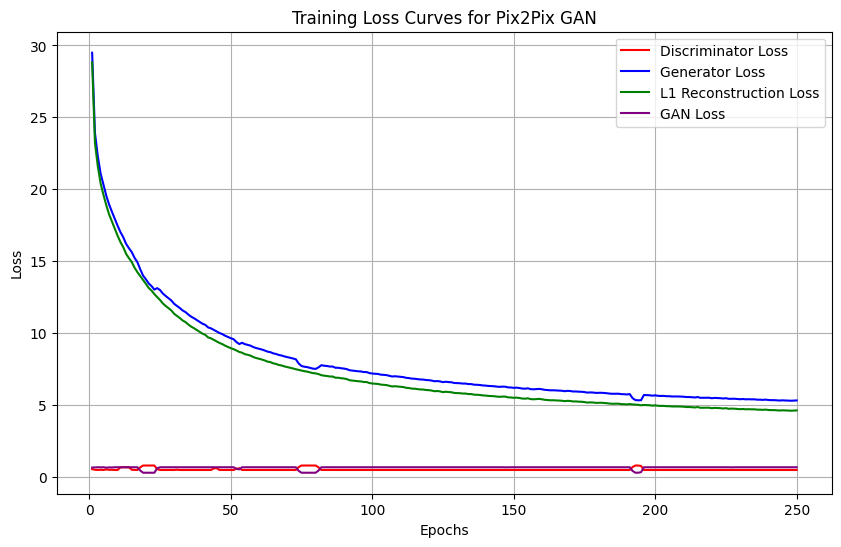

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

num_epochs = 250
d_losses, g_losses, l1_losses, gan_losses = [], [], [], []

for epoch in range(num_epochs):
    epoch_d_loss, epoch_g_loss, epoch_l1_loss, epoch_gan_loss = 0, 0, 0, 0
    num_batches = len(train_loader)

    for i, (masked_imgs, real_imgs) in enumerate(train_loader):
        masked_imgs, real_imgs = masked_imgs.to(device), real_imgs.to(device)


        optimizer_D.zero_grad()

        real_preds = discriminator(torch.cat((masked_imgs, real_imgs), 1))
        fake_imgs = generator(masked_imgs)
        fake_preds = discriminator(torch.cat((masked_imgs, fake_imgs.detach()), 1))

        real_labels = torch.ones_like(real_preds)
        fake_labels = torch.zeros_like(fake_preds)

        d_real_loss = criterion_GAN(real_preds, real_labels)
        d_fake_loss = criterion_GAN(fake_preds, fake_labels)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()


        optimizer_G.zero_grad()

        fake_preds = discriminator(torch.cat((masked_imgs, fake_imgs), 1))
        g_gan_loss = criterion_GAN(fake_preds, torch.ones_like(fake_preds))
        g_l1_loss = criterion_L1(fake_imgs, real_imgs) * 100



        g_loss = g_gan_loss + g_l1_loss
        g_loss.backward()
        optimizer_G.step()


        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_l1_loss += g_l1_loss.item()
        epoch_gan_loss += g_gan_loss.item()


    d_losses.append(epoch_d_loss / num_batches)
    g_losses.append(epoch_g_loss / num_batches)
    l1_losses.append(epoch_l1_loss / num_batches)
    gan_losses.append(epoch_gan_loss / num_batches)

    print(f"Epoch [{epoch+1}/{num_epochs}]  D Loss: {d_losses[-1]:.4f}  G Loss: {g_losses[-1]:.4f}  L1 Loss: {l1_losses[-1]:.4f}  GAN Loss: {gan_losses[-1]:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), d_losses, label="Discriminator Loss", color='red')
plt.plot(range(1, num_epochs + 1), g_losses, label="Generator Loss", color='blue')
plt.plot(range(1, num_epochs + 1), l1_losses, label="L1 Reconstruction Loss", color='green')
plt.plot(range(1, num_epochs + 1), gan_losses, label="GAN Loss", color='purple')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curves for Pix2Pix GAN")
plt.legend()
plt.grid()
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


generator = Generator().to(device)
discriminator = Discriminator().to(device)

print("✅ Generator and Discriminator initialized!")


✅ Generator and Discriminator initialized!


In [ ]:
generator_path = "/content/drive/MyDrive/FINAL PROJECT/MODELS/pix2pix_generator.pth"
discriminator_path = "/content/drive/MyDrive/FINAL PROJECT/MODELS/pix2pix_discriminator.pth"

generator.load_state_dict(torch.load(generator_path, map_location=device))
discriminator.load_state_dict(torch.load(discriminator_path, map_location=device))


generator.eval()
discriminator.eval()

print("✅ Generator and Discriminator loaded successfully for evaluation!")

<ipython-input-14-66a4a4712a3d>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load(generator_path, map_location=device))
<ipython-input-14

✅ Generator and Discriminator loaded successfully for evaluation!


In [ ]:
dataloader = DataLoader(train_dataset, batch_size=10, shuffle=False)

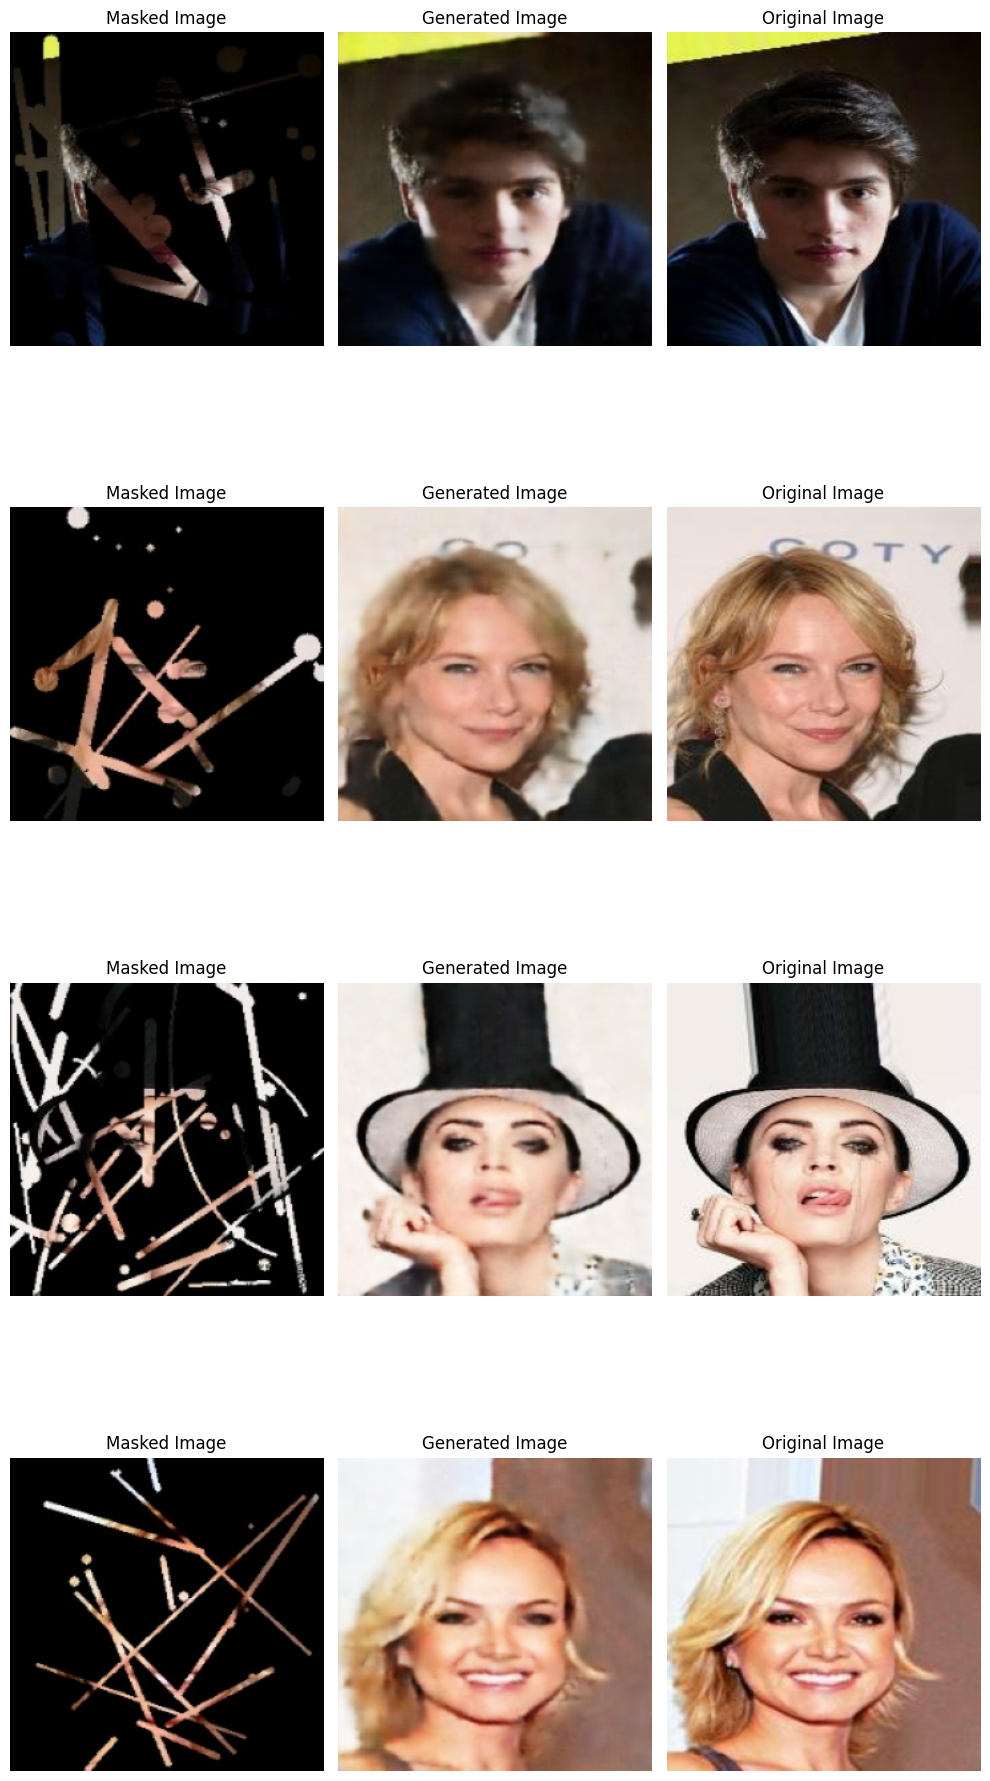

In [ ]:
import matplotlib.pyplot as plt

def show_images(masked_batch, generated_batch, real_batch, num_images=10):

    num_images = min(num_images, masked_batch.shape[0])
    fig, axes = plt.subplots(num_images, 3, figsize=(10, 5 * num_images))

    for i in range(num_images):

        axes[i, 0].imshow(masked_batch[i].permute(1, 2, 0).cpu().detach().numpy() * 0.5 + 0.5)
        axes[i, 0].set_title("Masked Image")
        axes[i, 0].axis("off")


        axes[i, 1].imshow(generated_batch[i].permute(1, 2, 0).cpu().detach().numpy() * 0.5 + 0.5)
        axes[i, 1].set_title("Generated Image")
        axes[i, 1].axis("off")


        axes[i, 2].imshow(real_batch[i].permute(1, 2, 0).cpu().detach().numpy() * 0.5 + 0.5)
        axes[i, 2].set_title("Original Image")
        axes[i, 2].axis("off")


    plt.tight_layout()
    plt.show()

masked_batch, real_batch = next(iter(train_loader))
masked_batch = masked_batch.to(device)
generated_batch = generator(masked_batch)
show_images(masked_batch, generated_batch, real_batch, num_images=10)



In [ ]:
torch.save(generator.state_dict(), "pix2pix_generator.pth")
torch.save(discriminator.state_dict(), "pix2pix_discriminator.pth")


In [ ]:
torch.save({
    'epoch': num_epochs,
    'generator_state_dict': generator.state_dict(),
    'discriminator_state_dict': discriminator.state_dict(),
    'optimizer_G_state_dict': optimizer_G.state_dict(),
    'optimizer_D_state_dict': optimizer_D.state_dict(),
    'g_losses': g_losses,
    'd_losses': d_losses
}, "pix2pix_checkpoint.pth")



In [ ]:
from PIL import Image
import torchvision.transforms as transforms
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((256, 256)),
])


test_image_path = "/content/drive/MyDrive/FINAL PROJECT/REAL IMAGES/002800.jpg"
test_image = Image.open(test_image_path).convert("RGB")

# Apply transformations
test_image = transform(test_image)
test_image = test_image.unsqueeze(0)

# Move to device (CPU/GPU)
test_image = test_image.to(device)

print("Test image shape:", test_image.shape)



Test image shape: torch.Size([1, 3, 256, 256])


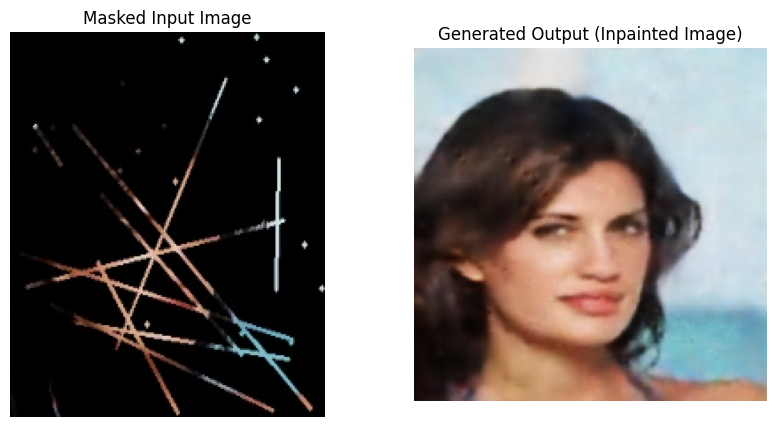

In [ ]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image

def preprocess_image(image_path, device, image_size=(256, 256)):
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    return image, image_tensor


def generate_inpainted_image(masked_image_path, generator, device):
    generator.eval()
    original_image, masked_tensor = preprocess_image(masked_image_path, device)


    with torch.no_grad():
        generated_tensor = generator(masked_tensor).cpu()


    to_pil = transforms.ToPILImage()
    generated_image = to_pil((generated_tensor.squeeze(0) * 0.5 + 0.5).clamp(0, 1))

    return original_image, generated_image


def display_results(masked_image_path, generator, device):
    original_image, generated_image = generate_inpainted_image(masked_image_path, generator, device)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(masked_image_path))
    plt.title("Masked Input Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(generated_image)
    plt.title("Generated Output (Inpainted Image)")
    plt.axis("off")

    plt.show()


masked_image_path = "/content/drive/MyDrive/FINAL PROJECT/masked_images/002800.jpg"  # Replace with your masked image path
display_results(masked_image_path, generator, device)


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def calculate_psnr(original, generated):
    """
    Compute the PSNR (Peak Signal-to-Noise Ratio) between original and generated images.

    Args:
        original (torch.Tensor): Ground truth image tensor (C, H, W) in range [0, 1]
        generated (torch.Tensor): Generated image tensor (C, H, W) in range [0, 1]

    Returns:
        float: PSNR value in dB.
    """
    mse = F.mse_loss(original, generated)
    if mse == 0:
        return float('inf')
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr.item()

def calculate_dataset_psnr(real_batch, generated_batch, device):
    """
    Compute the average PSNR for all images in the dataset.

    Args:
        real_batch (torch.Tensor): Batch of ground truth images (N, C, H, W)
        generated_batch (torch.Tensor): Batch of generated images (N, C, H, W)
        device (str): Device to perform computation on ("cuda" or "cpu")

    Returns:
        float: Average PSNR score for the dataset.
    """
    psnr_scores = []
    for i in range(real_batch.shape[0]):
        original = real_batch[i].to(device)
        generated = generated_batch[i].to(device)
        psnr_scores.append(calculate_psnr(original, generated))

    avg_psnr = np.mean(psnr_scores)
    return avg_psnr


real_batch = real_batch.to(device)
generated_batch = generated_batch.to(device)

average_psnr = calculate_dataset_psnr(real_batch, generated_batch, device)
print(f"Average PSNR Score: {average_psnr:.2f} dB")


Average PSNR Score: 20.98 dB


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def calculate_psnr(original, generated):
    """
    Compute the PSNR (Peak Signal-to-Noise Ratio) between original and generated images.

    Args:
        original (torch.Tensor): Ground truth image tensor (C, H, W) in range [0, 1]
        generated (torch.Tensor): Generated image tensor (C, H, W) in range [0, 1]

    Returns:
        float: PSNR value in dB.
    """
    mse = F.mse_loss(original, generated)
    if mse == 0:
        return float('inf')
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr.item()


original_img = real_batch[3].to(device)
generated_img = generated_batch[3].to(device)

psnr_value = calculate_psnr(original_img, generated_img)
print(f"PSNR Score: {psnr_value:.2f} dB")

PSNR Score: 22.53 dB


In [ ]:
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim

def calculate_ssim(generated_batch, real_batch):
    """
    Compute SSIM (Structural Similarity Index Measure) between generated and real images.

    Args:
        generated_batch (Tensor): Generated images (B, C, H, W).
        real_batch (Tensor): Real images (B, C, H, W).

    Returns:
        float: Average SSIM over the batch.
    """
    batch_size = generated_batch.shape[0]


    generated_batch = (generated_batch * 0.5) + 0.5
    real_batch = (real_batch * 0.5) + 0.5


    avg_ssim = 0
    for i in range(batch_size):
        gen_img_np = generated_batch[i].permute(1, 2, 0).cpu().numpy()
        real_img_np = real_batch[i].permute(1, 2, 0).cpu().numpy()

        min_dim = min(real_img_np.shape[:2])
        win_size = min(7, min_dim if min_dim % 2 != 0 else min_dim - 1)

        avg_ssim += ssim(real_img_np, gen_img_np, data_range=1.0, win_size=win_size, channel_axis=-1)

    avg_ssim /= batch_size

    return avg_ssim


with torch.no_grad():
    generated_batch = generator(masked_batch)
    generated_batch = generated_batch.to(device)


ssim_value = calculate_ssim(generated_batch, real_batch)

print(f"Average SSIM: {ssim_value:.4f}")


Average SSIM: 0.8366


In [ ]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
import torch
import lpips


loss_fn = lpips.LPIPS(net='vgg').to(device)

real_batch = real_batch.to(device)
generated_batch = generated_batch.to(device)

lpips_score = loss_fn(real_batch, generated_batch)
print(f"LPIPS Score: {lpips_score.mean().item():.4f}")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:10<00:00, 53.2MB/s]


Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/vgg.pth


/usr/local/lib/python3.11/dist-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cpu'), st

LPIPS Score: 0.2899
